사용 중인 폰트: Malgun Gothic
전체 데이터 건수: 681828
불법주정차 최다 발생 시간: 15시
발생 건수: 114,933건


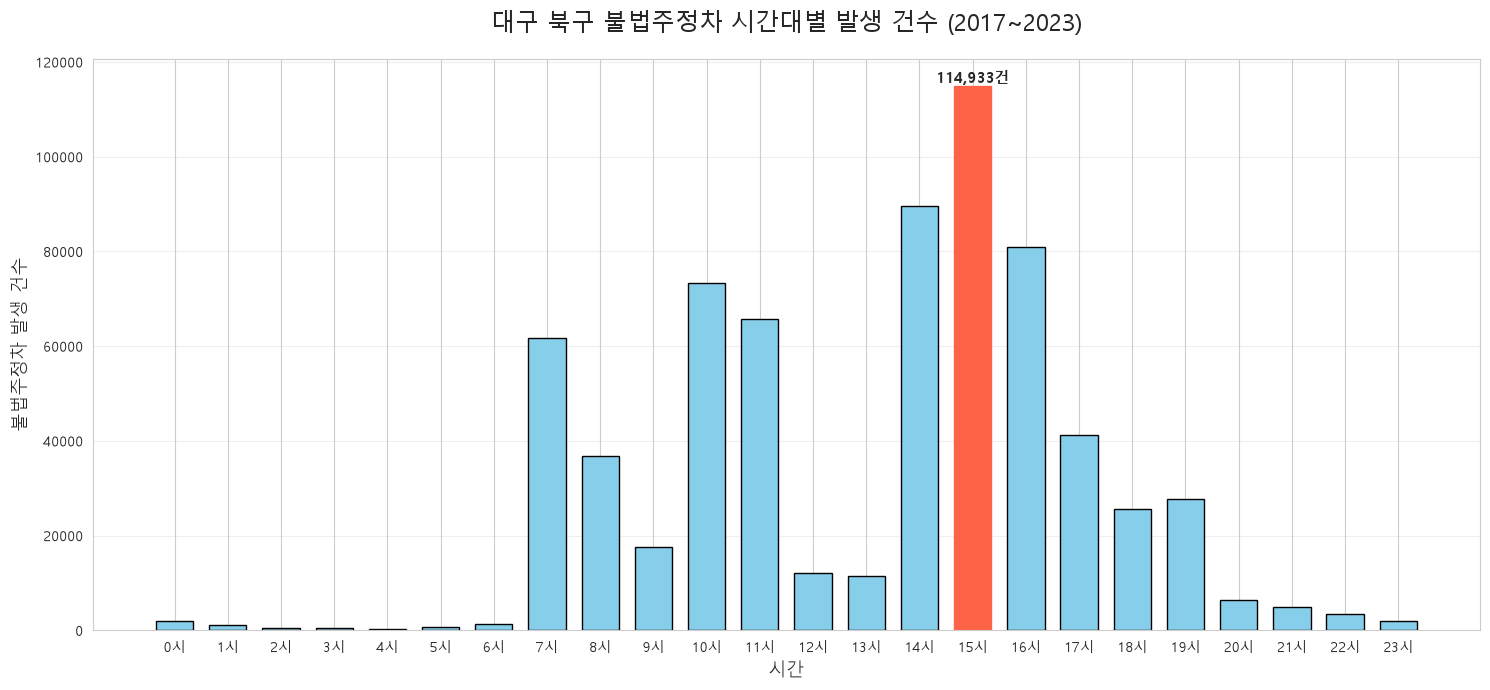


요일별 최다 발생 시간
월요일: 15시 (19,446건)
화요일: 15시 (18,771건)
수요일: 15시 (18,800건)
목요일: 15시 (18,958건)
금요일: 15시 (19,072건)
토요일: 14시 (9,955건)
일요일: 14시 (11,844건)


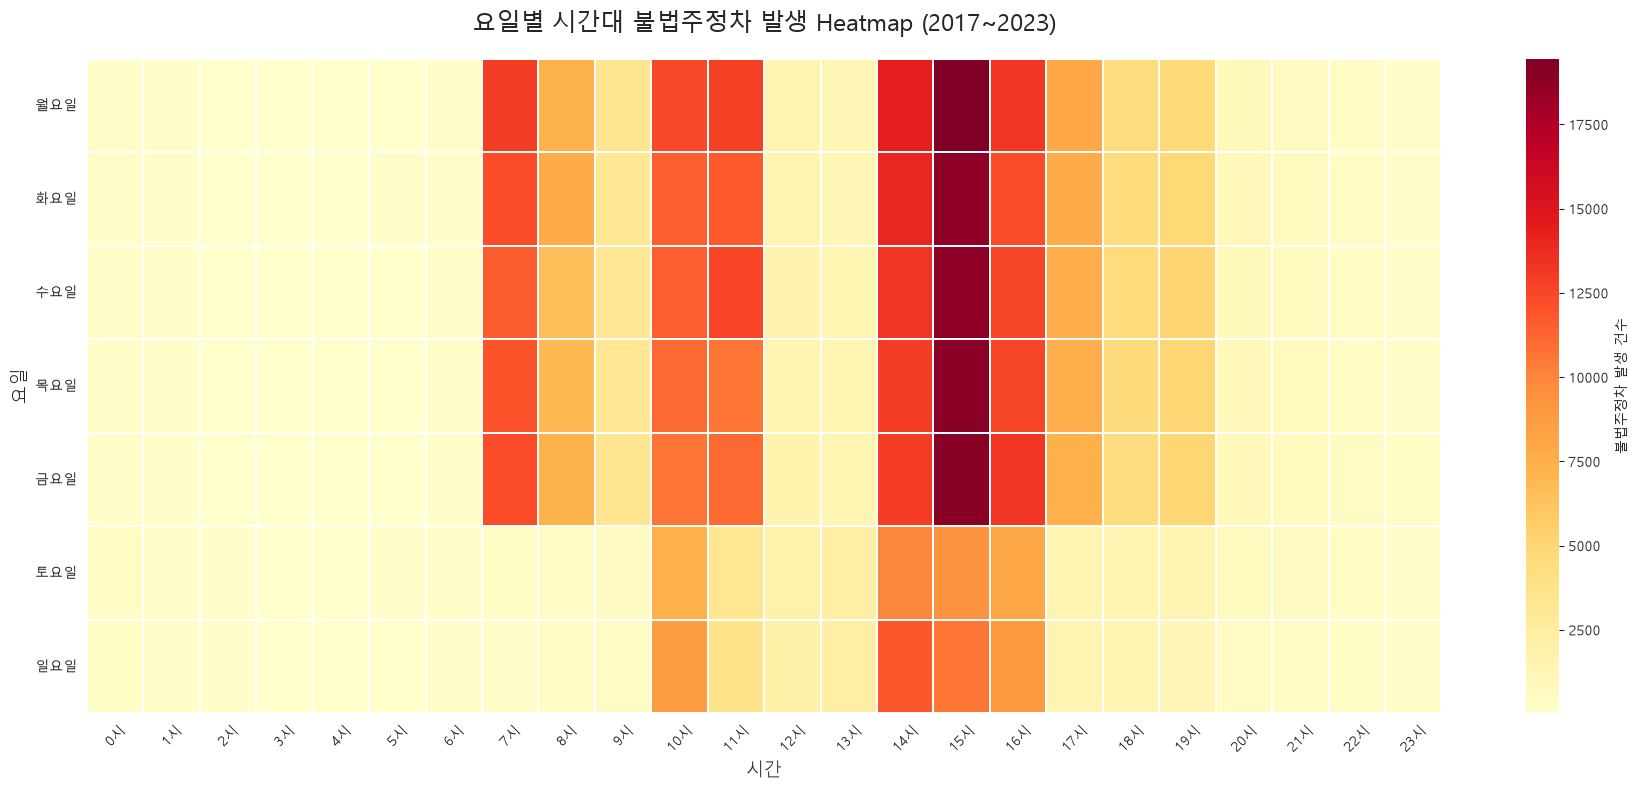


그래프 저장 완료!
저장 위치: C:\Users\Win11Pro\Documents\팀플1조~1008\18_kdt_01\notebooks\output


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns #그래프 스타일
from pathlib import Path


# ==================================================
# 1. 기본 설정
# ==================================================

# CSV 파일 경로
FILE_PATH = Path(
    r"../data/processed/violation_2017_2023.csv"
)

# 그래프 저장 경로
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


# ==================================================
# 2. 한글 폰트 설정
# ==================================================

# 윈도우 맑은 고딕 폰트 경로
font_path = "C:/Windows/Fonts/malgun.ttf"

# 폰트 등록
fm.fontManager.addfont(font_path)

# 폰트 이름 가져오기
font_name = fm.FontProperties(fname=font_path).get_name()

# 그래프 한글 폰트 설정
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

# 그래프 스타일
sns.set_style("whitegrid")

# 스타일 적용 후 한글 폰트 재설정
plt.rcParams["font.family"] = font_name

print("사용 중인 폰트:", font_name)


# ==================================================
# 3. 데이터 불러오기 및 전처리
# ==================================================

df = pd.read_csv(FILE_PATH, encoding="utf-8-sig")

# 시간 열 숫자로 변환
df["시간"] = pd.to_numeric(df["시간"], errors="coerce")

# 시간 데이터가 없는 행 제거
df = df.dropna(subset=["시간"])

# 0~23시 데이터만 사용
df = df[df["시간"].between(0, 23)]

# 시간 정수형 변환
df["시간"] = df["시간"].astype(int)

# 요일 순서 설정
weekday_order = [
    "월요일", "화요일", "수요일",
    "목요일", "금요일", "토요일", "일요일"
]

print("전체 데이터 건수:", len(df))


# ==================================================
# 4. 시간대별 불법주정차 막대그래프
# ==================================================

# 0~23시별 발생 건수 계산
hourly_counts = (
    df["시간"]
    .value_counts()
    .reindex(range(24), fill_value=0)
    .sort_index()
)

# 가장 많이 발생한 시간
peak_hour = hourly_counts.idxmax()
peak_count = hourly_counts.max()

print(f"불법주정차 최다 발생 시간: {peak_hour}시")
print(f"발생 건수: {peak_count:,}건")


# 그래프 생성
fig, ax = plt.subplots(figsize=(15, 7))

bars = ax.bar(
    hourly_counts.index,
    hourly_counts.values,
    width=0.7,
    color="skyblue",
    edgecolor="black"
)

# 최다 발생 시간 강조
bars[peak_hour].set_color("tomato")

# 최다 발생 건수 표시
ax.text(
    peak_hour,
    peak_count,
    f"{peak_count:,}건",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

# 그래프 제목 및 축 이름
ax.set_title(
    "대구 북구 불법주정차 시간대별 발생 건수 (2017~2023)",
    fontsize=17,
    pad=20
)

ax.set_xlabel("시간", fontsize=13)
ax.set_ylabel("불법주정차 발생 건수", fontsize=13)

# 가로축 0~23시 설정
ax.set_xticks(range(24))
ax.set_xticklabels([f"{i}시" for i in range(24)])

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

# 이미지 저장
plt.savefig(
    OUTPUT_DIR / "01_hourly_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================
# 5. 요일별 시간대 Heatmap
# ==================================================

# 요일별, 시간대별 발생 건수 계산
weekday_hour = pd.crosstab(
    df["요일"],
    df["시간"]
)

# 요일과 시간 순서 정렬
weekday_hour = weekday_hour.reindex(
    index=weekday_order,
    columns=range(24),
    fill_value=0
)

# 요일별 최다 발생 시간 출력
print("\n요일별 최다 발생 시간")

for day in weekday_order:
    if weekday_hour.loc[day].sum() > 0:
        max_hour = weekday_hour.loc[day].idxmax()
        max_count = weekday_hour.loc[day].max()

        print(
            f"{day}: {max_hour}시 "
            f"({max_count:,}건)"
        )


# Heatmap 생성
fig, ax = plt.subplots(figsize=(18, 8))

sns.heatmap(
    weekday_hour,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.3,
    cbar_kws={
        "label": "불법주정차 발생 건수"
    },
    ax=ax
)

# 그래프 제목 및 축 이름
ax.set_title(
    "요일별 시간대 불법주정차 발생 Heatmap (2017~2023)",
    fontsize=17,
    pad=20
)

ax.set_xlabel("시간", fontsize=13)
ax.set_ylabel("요일", fontsize=13)

# 가로축 시간 설정
ax.set_xticks([i + 0.5 for i in range(24)])
ax.set_xticklabels(
    [f"{i}시" for i in range(24)],
    rotation=45
)

# 세로축 요일 설정
ax.set_yticklabels(weekday_order, rotation=0)

plt.tight_layout()

# 이미지 저장
plt.savefig(
    OUTPUT_DIR / "02_weekday_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==================================================
# 6. 결과 확인
# ==================================================

print("\n그래프 저장 완료!")
print("저장 위치:", OUTPUT_DIR.resolve())